In [19]:
import pandas as pd

#EXPLORATORY DATA ANALYSIS
1. Read the files , convert the columns into the best suitable datatypes respectively. 
2. Identify any null values in the data. 
3. Check the min and max date in date columns, number of unique customers in each table and the quantile for amount.

In [20]:
#Read the data
application_df=pd.read_csv(r'applications (1).csv', dtype={'merchant_id':'string'})
print(f'Applications:\n{application_df.head()}\n\n')

drawdowns_df=pd.read_csv(r'drawdowns (1).csv',dtype={'merchant_id':'string'})
print(f'Drawdowns:\n{drawdowns_df.head()}\n\n')
drawdowns_df["merchant_id"] = drawdowns_df["merchant_id"].str.replace(r"\.00$", "", regex=True)


repayments_df=pd.read_csv(r'repayments (1).csv',dtype={'merchant_id':'string'})
print(f'Repayment:\n{repayments_df.head()}\n')

Applications:
  merchant_id applied_date
0   119486121   23-11-2021
1   113925737   14-08-2021
2   113925737   14-08-2021
3   131897474   03-12-2021
4   113753651   09-12-2021


Drawdowns:
    merchant_id  drawdown_amount drawdown_date
0  134829201.00             6000    21-04-2023
1  134829201.00             6000    22-04-2023
2  134829201.00             6000    23-04-2023
3  134829201.00             5168    24-04-2023
4  134829201.00             6500    27-04-2023


Repayment:
  merchant_id repaid_date    amount
0   113607807  31-08-2023      1.71
1   113607807  29-08-2023      4.39
2   113607807  23-08-2023     14.48
3   113607807  21-08-2023     22.50
4   113607807  31-08-2023  63967.55



In [21]:
# Formatting the date columns
application_df['applied_date'] = pd.to_datetime(application_df['applied_date'])
drawdowns_df['drawdown_date'] = pd.to_datetime(drawdowns_df['drawdown_date'])
repayments_df['repaid_date'] = pd.to_datetime(repayments_df['repaid_date'])
print(drawdowns_df.head())
# Sort the dfs on basis of ids and dates
drawdowns_df = drawdowns_df.sort_values(['merchant_id', 'drawdown_date']).reset_index(drop=True)
repayments_df = repayments_df.sort_values(['merchant_id', 'repaid_date']).reset_index(drop=True)
print(drawdowns_df.head())

  merchant_id  drawdown_amount drawdown_date
0   134829201             6000    2023-04-21
1   134829201             6000    2023-04-22
2   134829201             6000    2023-04-23
3   134829201             5168    2023-04-24
4   134829201             6500    2023-04-27
  merchant_id  drawdown_amount drawdown_date
0   100274288            50000    2023-11-20
1   100274288            49000    2023-11-22
2   100274288           101000    2023-11-24
3   100274288            14000    2023-12-26
4   100274288            20000    2023-12-26


In [22]:
#ANALYSIS OF DFs
print("APPLICATION DF\n")
print(f"shape of app df:{application_df.shape}")
print(f"number of unique applicants:{application_df['merchant_id'].nunique()}")
print(f"max_app_date:{application_df['applied_date'].max()}  min_app_date:{application_df['applied_date'].min()}")
print(application_df[application_df.isna().any(axis=1)])
      
print("DRAWDOWN \n")
print(f"shape of ddf df:{drawdowns_df.shape}")
print(f"number of unique ddf:{drawdowns_df['merchant_id'].nunique()}")
print(f"max_dd_date:{drawdowns_df['drawdown_date'].max()}  min_dd_date:{drawdowns_df['drawdown_date'].min()}")
print(drawdowns_df[drawdowns_df.isna().any(axis=1)])

print("REPAYMENTS \n")
print(f"shape of rf df:{repayments_df.shape}")
print(f"number of unique repayers:{repayments_df['merchant_id'].nunique()}")
print(f"max_rp_date:{repayments_df['repaid_date'].max()}  min_rp_date:{repayments_df['repaid_date'].min()}")
print(repayments_df[repayments_df.isna().any(axis=1)])


APPLICATION DF

shape of app df:(398, 2)
number of unique applicants:370
max_app_date:2024-11-07 00:00:00  min_app_date:2021-03-12 00:00:00
Empty DataFrame
Columns: [merchant_id, applied_date]
Index: []
DRAWDOWN 

shape of ddf df:(18750, 3)
number of unique ddf:357
max_dd_date:2024-12-07 00:00:00  min_dd_date:2023-01-05 00:00:00
Empty DataFrame
Columns: [merchant_id, drawdown_amount, drawdown_date]
Index: []
REPAYMENTS 

shape of rf df:(42676, 3)
number of unique repayers:345
max_rp_date:2024-12-06 00:00:00  min_rp_date:2023-01-05 00:00:00
Empty DataFrame
Columns: [merchant_id, repaid_date, amount]
Index: []


In [23]:
print(drawdowns_df.head())
print(repayments_df.head())
print(drawdowns_df.dtypes)
print(repayments_df.dtypes)


  merchant_id  drawdown_amount drawdown_date
0   100274288            50000    2023-11-20
1   100274288            49000    2023-11-22
2   100274288           101000    2023-11-24
3   100274288            14000    2023-12-26
4   100274288            20000    2023-12-26
  merchant_id repaid_date   amount
0   100274288  2023-07-11  2357.00
1   100274288  2023-07-11     3.75
2   100274288  2023-07-12     5.28
3   100274288  2023-11-21     5.34
4   100274288  2023-11-24     5.00
merchant_id                string
drawdown_amount             int64
drawdown_date      datetime64[ns]
dtype: object
merchant_id            string
repaid_date    datetime64[ns]
amount                float64
dtype: object


<AxesSubplot:xlabel='applied_date'>

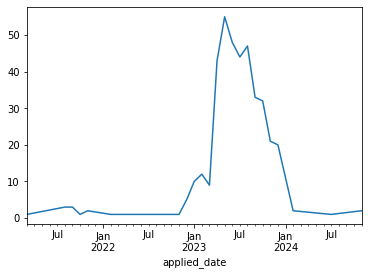

In [24]:
application_df.groupby(application_df["applied_date"].dt.to_period("M")).size().plot()

<AxesSubplot:>

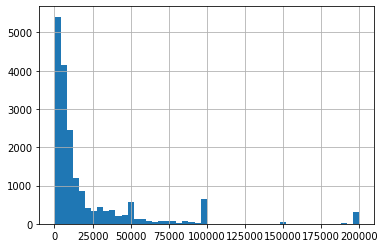

In [25]:
drawdowns_df["drawdown_amount"].hist(bins=50)

<AxesSubplot:>

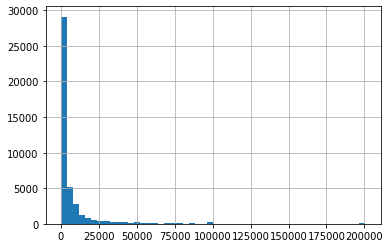

In [26]:
repayments_df["amount"].hist(bins=50)

In [27]:
drawdowns_df["next_drawdown_date"] = (
    drawdowns_df.groupby("merchant_id")["drawdown_date"].shift(-1)
)
print(drawdowns_df)
merged_df = drawdowns_df.merge(
    repayments_df,
    on="merchant_id",
    how="left"
)
print(merged_df.head())
print(merged_df.shape)

      merchant_id  drawdown_amount drawdown_date next_drawdown_date
0       100274288            50000    2023-11-20         2023-11-22
1       100274288            49000    2023-11-22         2023-11-24
2       100274288           101000    2023-11-24         2023-12-26
3       100274288            14000    2023-12-26         2023-12-26
4       100274288            20000    2023-12-26                NaT
...           ...              ...           ...                ...
18745   157046625             4800    2023-12-09                NaT
18746   157639593             3000    2023-10-17         2023-10-18
18747   157639593             5000    2023-10-18         2023-10-20
18748   157639593             5000    2023-10-20         2023-12-10
18749   157639593             4005    2023-12-10                NaT

[18750 rows x 4 columns]
  merchant_id  drawdown_amount drawdown_date next_drawdown_date repaid_date  \
0   100274288            50000    2023-11-20         2023-11-22  2023-07-11   


In [28]:
final_df= merged_df[
    (merged_df["repaid_date"] >= merged_df["drawdown_date"]) &
    (
        (merged_df["repaid_date"] < merged_df["next_drawdown_date"]) |
        (merged_df["next_drawdown_date"].isna())  # last drawdown case
    )
]
final_df.head(10)

,merchant_id,drawdown_amount,drawdown_date,next_drawdown_date,repaid_date,amount
3,100274288,50000,2023-11-20,2023-11-22,2023-11-21,5.34
52,100274288,101000,2023-11-24,2023-12-26,2023-11-24,5.00
53,100274288,101000,2023-11-24,2023-12-26,2023-12-24,1398.55
54,100274288,101000,2023-11-24,2023-12-26,2023-12-25,50000.00
103,100274288,20000,2023-12-26,NaT,2023-12-26,50000.00
104,100274288,20000,2023-12-26,NaT,2023-12-26,5.00
105,100274288,20000,2023-12-26,NaT,2023-12-27,33395.00
106,100274288,20000,2023-12-26,NaT,2023-12-28,600.00
107,100274288,20000,2023-12-26,NaT,2024-01-06,20000.00
108,100274288,20000,2023-12-26,NaT,2024-01-20,1500.00


In [29]:
#CREATING A LEDGER

In [30]:
draw_events = drawdowns_df[["merchant_id", "drawdown_date", "drawdown_amount"]]
print(draw_events.shape)

draw_events = draw_events.rename(columns={"drawdown_date": "date","drawdown_amount": "amount"})

draw_events["type"] = "drawdown"

(18750, 3)


In [31]:
repay_events = repayments_df[["merchant_id", "repaid_date", "amount"]].rename(columns={"repaid_date": "date"})
repay_events["type"] = "repayment"

In [32]:
first_drawdown = draw_events.groupby("merchant_id")["date"].min()
repay_events = repay_events.merge(
    first_drawdown.rename("first_drawdown_date"),
    on="merchant_id",
    how="left"
)
repay_clean_df = repay_events[
    repay_events["date"] >= repay_events["first_drawdown_date"]
]

In [33]:
ledger = pd.concat([draw_events, repay_clean_df.drop('first_drawdown_date',axis=1)], ignore_index=True)

In [34]:
ledger["type_order"] = ledger["type"].map({"drawdown": 0,"repayment": 1})

ledger = ledger.sort_values(["merchant_id", "date", "type_order"])

In [35]:
ledger["signed_amount"] = ledger.apply(lambda x: x["amount"] if x["type"] == "drawdown" else -x["amount"],axis=1)
ledger.head(20)

,merchant_id,date,amount,type,type_order,signed_amount
0,100274288,2023-11-20,50000.00,drawdown,0,50000.00
18750,100274288,2023-11-21,5.34,repayment,1,-5.34
1,100274288,2023-11-22,49000.00,drawdown,0,49000.00
2,100274288,2023-11-24,101000.00,drawdown,0,101000.00
18751,100274288,2023-11-24,5.00,repayment,1,-5.00
18752,100274288,2023-12-24,1398.55,repayment,1,-1398.55
18753,100274288,2023-12-25,50000.00,repayment,1,-50000.00
3,100274288,2023-12-26,14000.00,drawdown,0,14000.00
4,100274288,2023-12-26,20000.00,drawdown,0,20000.00
18754,100274288,2023-12-26,50000.00,repayment,1,-50000.00


In [36]:
ledger["outstanding_balance"] = ledger.groupby("merchant_id")["signed_amount"].cumsum()
ledger.head(20)

,merchant_id,date,amount,type,type_order,signed_amount,outstanding_balance
0,100274288,2023-11-20,50000.00,drawdown,0,50000.00,50000.00
18750,100274288,2023-11-21,5.34,repayment,1,-5.34,49994.66
1,100274288,2023-11-22,49000.00,drawdown,0,49000.00,98994.66
2,100274288,2023-11-24,101000.00,drawdown,0,101000.00,199994.66
18751,100274288,2023-11-24,5.00,repayment,1,-5.00,199989.66
18752,100274288,2023-12-24,1398.55,repayment,1,-1398.55,198591.11
18753,100274288,2023-12-25,50000.00,repayment,1,-50000.00,148591.11
3,100274288,2023-12-26,14000.00,drawdown,0,14000.00,162591.11
4,100274288,2023-12-26,20000.00,drawdown,0,20000.00,182591.11
18754,100274288,2023-12-26,50000.00,repayment,1,-50000.00,132591.11


In [38]:
ledger.to_csv('ledger.csv', index=False)